In [60]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_csv("telecom_customer_churn.csv")

# ==============================
# 2. CLEAN TARGET
# ==============================
df["Churn"] = df["Churn"].astype(str).str.strip().str.lower()
df["Churn"] = df["Churn"].map({"yes": 1, "no": 0})

# ==============================
# 3. FIX TOTALCHARGES
# ==============================
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# ==============================
# 4. DROP USELESS COLUMN
# ==============================
df.drop("customerID", axis=1, inplace=True)

# ==============================
# 5. HANDLE BINARY CATEGORICAL
# ==============================
cat_cols = df.select_dtypes(include="object").columns

binary_cols = [col for col in cat_cols if df[col].nunique() == 2]

for col in binary_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    
    unique_vals = set(df[col].unique())
    
    if unique_vals <= {"yes", "no"}:
        df[col] = df[col].map({"yes": 1, "no": 0})
        
    elif unique_vals <= {"male", "female"}:
        df[col] = df[col].map({"female": 1, "male": 0})

# ==============================
# 6. HANDLE MULTI-CLASS CATEGORICAL
# ==============================
cat_cols = df.select_dtypes(include="object").columns  # recompute

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# ==============================
# 7. SCALE NUMERICAL FEATURES
# ==============================
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# ==============================
# 8. FINAL CHECK
# ==============================
print(df.shape)
print(df.info())
print(df.head())

(7043, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   float64
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool  

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16780\3977886864.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [61]:
print(df.isnull().sum().sum())  # should be 0
print(df.select_dtypes(include="object").columns)  # should be empty

0
Index([], dtype='object')


In [62]:
## Pipeline
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

cat_cols = X_train.select_dtypes(include="uint8").columns

In [64]:
# Build Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [66]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[934 102]
 [149 224]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [67]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[749 287]
 [ 65 308]]
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [ ]:
model.predict_proba(X_test)[:5]

array([[0.15272558, 0.84727442],
       [0.83861934, 0.16138066],
       [0.98669665, 0.01330335],
       [0.19710254, 0.80289746],
       [0.98113473, 0.01886527]])

what does balance class weight do
if model is favouring any class either 0 or 1 more
balancing shifts the decion boundary towards minority class
class_weight doesn’t change probabilities directly — it changes how model learns them

Class weight influences how the model learns by penalizing errors differently, while threshold controls the final decision boundary during prediction

In [71]:
# Hour 6
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("AUC:", auc_score)

AUC: 0.8620661546264764


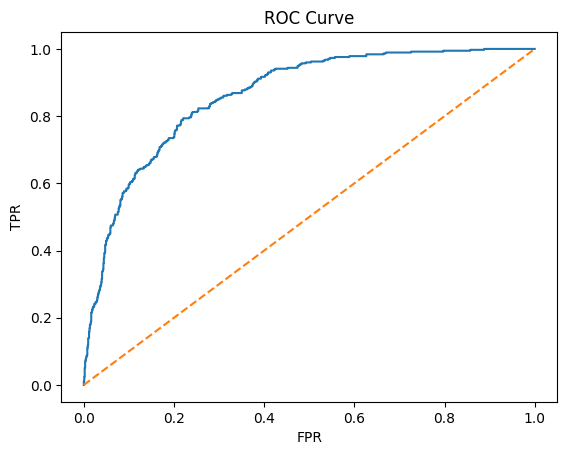

In [74]:
# Plot ROC curve

import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")  # random line
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

In [76]:
# Hour 7
# Try different thresholds

import numpy as np
threshold = 0.3
y_pred_custom = (y_prob>=threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.96      0.55      0.70      1036
           1       0.43      0.94      0.59       373

    accuracy                           0.65      1409
   macro avg       0.70      0.75      0.64      1409
weighted avg       0.82      0.65      0.67      1409



In [77]:
# Try multiple threshold

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.96      0.55      0.70      1036
           1       0.43      0.94      0.59       373

    accuracy                           0.65      1409
   macro avg       0.70      0.75      0.64      1409
weighted avg       0.82      0.65      0.67      1409


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.94      0.63      0.76      1036
           1       0.46      0.88      0.61       373

    accuracy                           0.70      1409
   macro avg       0.70      0.76      0.68      1409
weighted avg       0.81      0.70      0.72      1409


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81   

In [ ]:
# Scenario	                    Method
# Fixed % customers           	Top probabilities ✔
# Control FP/FN	                Threshold ✔

In [ ]:
# if business say we can contact 30% of the customers onyl

y_prob = model.predict_proba(X_test)[:,1]

# Sort customers
import numpy as np
top_k = int(0.3*len(y_prob))
print(len(y_prob))
print(top_k)

top_indices = np.argsort(y_prob)[-top_k:]

# Argsort doesnot return vallues it returns the indices

# to target top 30 customers we use from X_test set
top_thirty = X_test.iloc[top_indices]

# During evaluation, we use X_test to validate model performance.
# In production, we apply the trained model on the 
# full dataset and select top customers based on predicted probabilities.”
model.fit(X_train, y_train)
y_prob_all = model.predict_proba(X)[:,1]
import numpy as np
top_k = int(0.30 * len(y_prob_all))
top_indices_all = np.argsort(y_prob_all)[-top_k:]

# final target customers
target_customers = X.iloc[top_indices_all]

# Train on train → Evaluate on test → Deploy on full data

# Train model → Deploy → Predict on new data → Monitor → Retrain periodically
# We dont retrain for each new customers , we retrain periodically
# We do not retrain the model for every new customer.
# Instead, we use the trained model to make predictions on new data and 
# retrain periodically or when model performance degrades.

1409
422


In [87]:
## DSA
# Find the smallest subarray with sum>= target
nums = [2,3,1,2,4,3]
target = 7

def minSubArrayLen(target, nums):
    left = 0
    window_sum = 0
    min_len = float('inf')
    
    for right in range(len(nums)):
        window_sum += nums[right]
        
        while window_sum >= target:
            min_len = min(min_len, right - left + 1)
            window_sum -= nums[left]
            left += 1
    
    return 0 if min_len == float('inf') else min_len

print(minSubArrayLen(target,nums))

2


In [99]:
# Problem

# Replace at most k characters
# Get longest substring with same char

s = "AABABBA"
k = 1
def characterReplacement(s, k):
    count = {}
    left = 0
    max_freq = 0
    max_len = 0
    
    for right in range(len(s)):
        count[s[right]] = count.get(s[right], 0) + 1
        max_freq = max(max_freq, count[s[right]])
        
        while (right - left + 1) - max_freq > k:
            count[s[left]] -= 1
            left += 1
        
        max_len = max(max_len, right - left + 1)
    
    return max_len
print(characterReplacement(s,k))

4
